# Laboratorio integrador: analizador de tendencias en noticias argentinas

**Duración estimada:** 1 hora

## Desafío
Vas a construir un sistema en Python que extraiga noticias de la web y las procese con `spaCy` para identificar entidades, verbos frecuentes, palabras clave y visualizaciones básicas.

## Resultados esperados
Al finalizar este laboratorio, vas a poder:
- extraer texto desde una URL periodística;
- encapsular análisis lingüístico en una clase reutilizable;
- generar visualizaciones a partir del texto procesado;
- integrar varias piezas en un pipeline simple de análisis de noticias.

## Modalidad de trabajo: pair programming con IA
En esta cátedra, `pair programming con IA` significa que la unidad de trabajo está formada por vos y un asistente de IA.

La IA puede ayudarte a:
- proponer estrategias;
- explicarte errores o mensajes del entorno;
- sugerir casos de prueba;
- comparar enfoques posibles;
- auditar código que ya escribiste.

La IA no reemplaza tu pensamiento. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu criterio.

## Bitácora breve de interacción con IA
Completá al menos una entrada por cada parte del laboratorio.

**Plantilla sugerida**
- Objetivo de la consulta.
- Prompt o pedido que hiciste.
- Qué te devolvió la IA.
- Qué conservaste.
- Qué corregiste o descartaste.
- Qué aprendiste del intercambio.


In [1]:
# Instalamos las librerías necesarias en modo silencioso (-q)
!pip install spacy trafilatura pandas matplotlib wordcloud nbformat plotly -q
!python -m spacy download es_core_news_lg -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


*Comentario:*
Al finalizar el trabajo me aparecía un error que no tenía nbformat instalado, así que lo sumé al bloque inicial y siguió con el mismo error.
Si bien reinicié el kernel, el error persistió así que el asistente IA me recomendó que lo añada en una celda aparte. Funcionó.
Luego, revisando si podría optimizar el código, el asistente recomendó que esté al inicio de la sentencia. Por el momento, lo dejé como está en este laboratorio al momento de la entrega.

In [2]:
!pip install nbformat --upgrade


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Importación de librerías
import spacy
import trafilatura
import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.graph_objects as go

nlp = spacy.load("es_core_news_lg")
print("Modelo y librerías cargadas.")

Modelo y librerías cargadas.


## Parte 1: extracción de noticias (15 minutos)

**Objetivo:** construir una función que reciba una URL y devuelva un diccionario con el texto limpio de la noticia.

**Antes de escribir código, hace esta consulta a la IA:**
- Pedile dos estrategias posibles para descargar y extraer el contenido principal de una página.
- Elegí una y explicá por qué.

**Recordatorio:** si la IA te propone código, revisalo antes de incorporarlo.


Las noticias elegidas refieren al uso de la IA para generación de imágenes o videos, donde tenemos parte legal y ética. Son las tres de este año y de distinta fuente.

*Comentario:* 
El asistente me propuso que trabaje con dos enfoques, uno con BeautilSoup y Request y la otra opción con Trafilatura. Entiendo que no puedo usar en todos los casos esos métodos dependiendo del sitio que elija ya que pueden ser dinámicos. Voy con Trafilatura y Playwright, si es que lo necesito.

Probamos con trafilatura:

In [4]:
from urllib.parse import urlparse

def extraer_noticias_web(urls_noticias):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    noticias = []
    
    for url in urls_noticias:
        try:
            descarga = trafilatura.fetch_url(url)
            texto = trafilatura.extract(descarga, include_comments=False, include_images=False)
            
            if texto:
                fuente = urlparse(url).netloc.replace("www.", "")
                noticias.append({
                    "fuente": fuente,
                    "texto": texto,
                    "origen": "web",
                    "url": url
                })
            else: 
                print (f"Advertencia: no se pudo extraer texto de {url}")
        except Exception as e:
            print(f"Error procesando {url}: {e}")
    return noticias

In [5]:
urls_noticias = [
                "https://www.infobae.com/tecno/2026/03/25/openai-confirma-que-abandonara-sora-su-aplicacion-para-generar-videos-con-ia/",
                "https://www.perfil.com/noticias/columnistas/el-futuro-que-duro-seis-meses-por-joan-cwaik.phtml",
                "https://cenital.com/la-inteligencia-artificial-no-muestra-el-pasado-lo-reescribe/"
]

noticias = extraer_noticias_web (urls_noticias)

df_web = pd.DataFrame(noticias)

df_web.head()

,fuente,texto,origen,url
0,infobae.com,"OpenAI, pionera en inteligencia artificial, co...",web,https://www.infobae.com/tecno/2026/03/25/opena...
1,perfil.com,"En septiembre de 2025, Sora llegó a la App Sto...",web,https://www.perfil.com/noticias/columnistas/el...
2,cenital.com,La inteligencia artificial no muestra el pasad...,web,https://cenital.com/la-inteligencia-artificial...


*Comentario:*
- Con el asistente probé en sumar la fuente ya que me parecía importante destacar de dónde provienen esas noticias. Lo que me recomendó y dejé es 
from urllib.parse import urlparse
la librería que ayuda a descomponer una URL.
- Descarté una noticia de Página 12 al pelear constantemente con el Playwright. Las recomendaciones del asistente sobre cómo actuar no pudieron solucionar el problema.

## Parte 2: análisis de texto con spaCy (20 minutos)

**Objetivo:** encapsular el análisis en una clase `AnalizadorNoticia`.

**Consulta sugerida a la IA antes de completar los métodos:**
- Pedile un mapa de responsabilidades para la clase.
- Pedile criterios para distinguir personas, organizaciones y lugares a partir de `ent.label_`.
- Después compara esa propuesta con la documentación o con las salidas del modelo.


In [6]:
class AnalizadorNoticia:
    def __init__(self, texto, nlp_model):
        """
        Inicializa el analizador con un texto y un modelo de spaCy ya cargado.
        """
        self.texto_original = texto
        self.nlp = nlp_model
        self.doc = self.nlp(texto)
        #self.doc = None

    def obtener_entidades(self):
        """Devuelve un diccionario con entidades agrupadas por tipo."""
        entidades = {
            'PERSONAS': [],
            'ORGANIZACIONES': [],
            'LUGARES': [],
            'OTROS': []
        }

        for ent in self.doc.ents:
            if ent.label_ == 'PER':
                entidades['PERSONAS'].append(ent.text)
            elif ent.label_ == 'ORG':
                entidades['ORGANIZACIONES'].append(ent.text)
            elif ent.label_ == 'LOC':
                entidades['LUGARES'].append(ent.text)
            else:
                entidades['OTROS'].append(ent.text)
        
        for clave in entidades:
            entidades[clave] = list(set(entidades[clave]))

        return entidades
    
    def obtener_verbos_principales(self, n=10):
        """Devuelve una lista de tuplas (verbo_lematizado, frecuencia)."""
        verbos = [token.lemma_.lower() for token in self.doc 
                  if token.pos_ == "VERB" and token.is_alpha]
        frecuencias = Counter(verbos)
        return frecuencias.most_common(n)

    def obtener_estadisticas(self):
        """Calcula estadísticas descriptivas básicas del texto."""
        total_tokens = len(self.doc)
        total_oraciones = len(list(self.doc.sents))

        palabras = [token.text.lower() for token in self.doc if not token.is_punct]
        palabras_unicas = len(set(palabras))
        
        longitud_promedio = total_tokens / total_oraciones if total_oraciones > 0 else 0

        return {
            'total_tokens': total_tokens,
            'total_oraciones': total_oraciones,
            'palabras_unicas': palabras_unicas,
            'longitud_promedio_oracion': round(longitud_promedio, 2),
        }

    def extraer_frases_con_entidad(self, nombre_entidad):
        """Devuelve oraciones que contengan una entidad específica."""
        oraciones = []

        for sent in self.doc.sents:
            if nombre_entidad.lower() in sent.text.lower():
                oraciones.append(sent.text.strip())
        return oraciones

In [7]:
resultados_nlp = []
for index, fila in df_web.iterrows():
    analizador = AnalizadorNoticia(fila['texto'], nlp)
    
    entidades = analizador.obtener_entidades()
    stats = analizador.obtener_estadisticas()
    verbos = analizador.obtener_verbos_principales(n=5)
    
    resultados_nlp.append({
        'fuente': fila['fuente'],
        'total_tokens': stats['total_tokens'],
        'personas': ", ".join(entidades['PERSONAS']),
        'organizaciones': ", ".join(entidades['ORGANIZACIONES']),
        'lugares': ", ".join(entidades['LUGARES']),
        'verbos_clave': [v[0] for v in verbos]
    })

df_final = pd.DataFrame(resultados_nlp)
display(df_final)

,fuente,total_tokens,personas,organizaciones,lugares,verbos_clave
0,infobae.com,683,"Claude Cowork, Fidji Simo, Disney","OpenAI, Cambio de estrategia, Google, IA",,"[permitir, confirmar, marcar, implicar, integrar]"
1,perfil.com,653,"Sora, Especialista, Empresas, Disney","OpenAI, Escribías, IA","Stadia, Vine","[aparecer, cerrar, llegar, construir, ocurrir]"
2,cenital.com,1740,"Bourdain, Disney, John Searle, Reemplazar, Ant...","IA, Roadrunner, Procesar, OpenAI, Google","Acá, California, Cenital, Hollywood","[hacer, hacer él, existir, creer, ver]"


*Comentarios:*
- El mapa de responsabilidades está cubierto por la clase empleada. 
- Para el modelo en español, a partir de 'ent.label', generó una clasificación de palabras en Personas, Organizaciones, Lugares y Otros. En este caso en particular hay algunos
falsos positivos, por así decir, entendiendo que puede ser una limitación del modelo. Por ejemplo, como verbo "hacer él", personas "Empresas"/"Reemplazar" u organización "Cambio de estrategia"/"Escribías".


## Parte 3: visualización de resultados (20 minutos)

**Objetivo:** construir dos visualizaciones simples a partir del texto procesado.

**Consulta sugerida a la IA:**
- Pedile criterios para decidir qué tokens conviene excluir de una nube de palabras.
- Pedile una propuesta de estructura para un gráfico de barras horizontal.
- Después revisa si esas sugerencias se ajustan a tu caso.


*Comentarios:*
- En este item conviene filtrar por las stopwords, puntuación y tokens no alfabéticos.
- El asistente recomendó trabajar con lema en lugar del texto original, por la temática del tema.

In [8]:
import plotly.graph_objects as go
import seaborn as sns

def crear_nube_palabras(doc_procesado):
    """Crea y muestra una nube de palabras a partir de un Doc de spaCy."""
    palabras_relevantes = [token.lemma_.lower() 
        for token in doc_procesado 
        if not token.is_stop 
        and not token.is_punct 
        and token.is_alpha 
        and len(token.lemma_) > 2 #sugerencia del asistente para palabras cortas
        and token.pos_ in ['NOUN', 'VERB', 'PROPN', 'ADJ'] #sugerencia del asistente para trabajar con palabras clave
    ]

    texto_limpio = ' '.join(palabras_relevantes)

    if texto_limpio:
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            collocations=False,
        ).generate(texto_limpio)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title("Nube de Palabras (Lemas Relevantes)")
        plt.show()
    else:
        print("No hay suficientes palabras relevantes para generar la nube.")


def visualizar_entidades_mas_comunes(entidades_dict, n=10, ax=None):
    todas_entidades = [ent for sublist in entidades_dict.values() for ent in sublist]
    frecuencias = Counter(todas_entidades)
    entidades_comunes = frecuencias.most_common(n)

    if not entidades_comunes:
        print("No se encontraron entidades para visualizar.")
        return

    df_ents = pd.DataFrame(entidades_comunes, columns=['Entidad', 'Frecuencia'])

    # Color de acento: la más frecuente destacada, el resto gris
    colores = ['#b0b0b0'] * len(df_ents)
    colores[0] = sns.color_palette("colorblind")[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    sns.barplot(
        data=df_ents,
        y='Entidad',
        x='Frecuencia',
        hue='Entidad',
        palette=colores,
        orient='h',
        order=df_ents['Entidad'],
        ax=ax,
        legend=False
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=5, fontweight='bold', fontsize=10, color='#333333')

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    ax.set_title('Top entidades nombradas', fontsize=13, fontweight='bold', pad=12, loc='left')

*Comentarios*:
En la siguiente sección había pensado en la estructura: Título + Nube de palabras + Gráfico de barras para cada noticia. Le pedí al asistente que me sugiera cambios en ese código para que me quede un gráfico al lado del otro para cada noticia.
Además, está revisada la paleta de colores según la guía.

Fuente: infobae.com


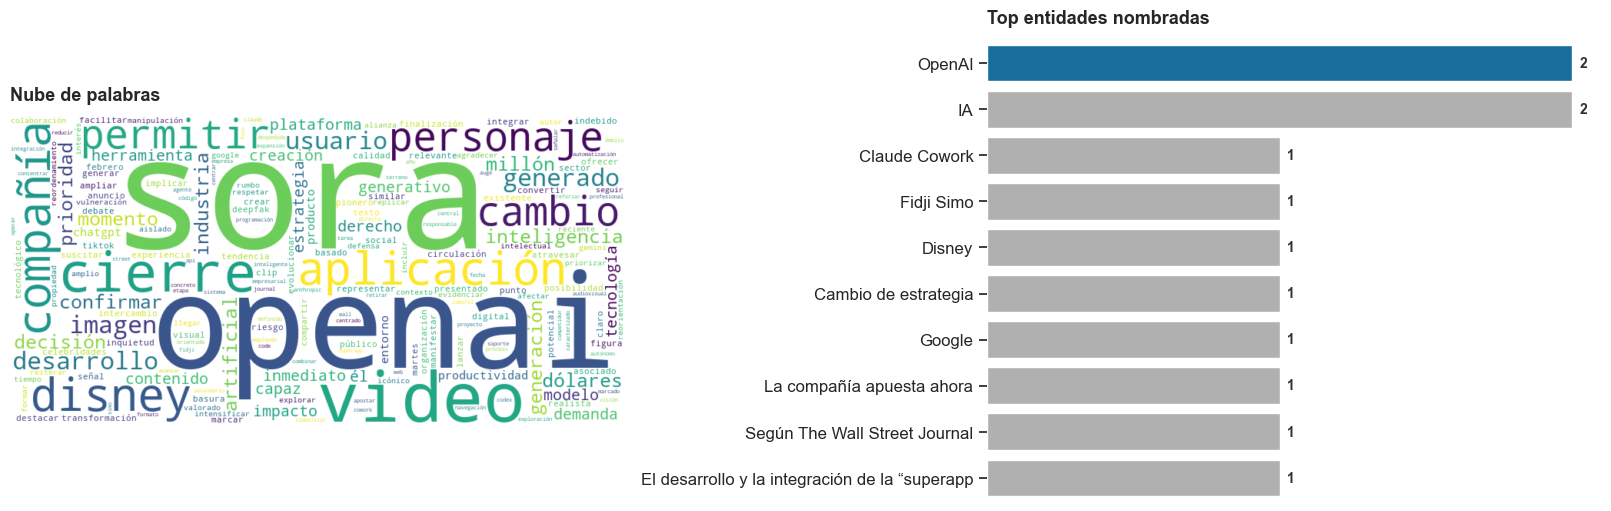

Fuente: perfil.com


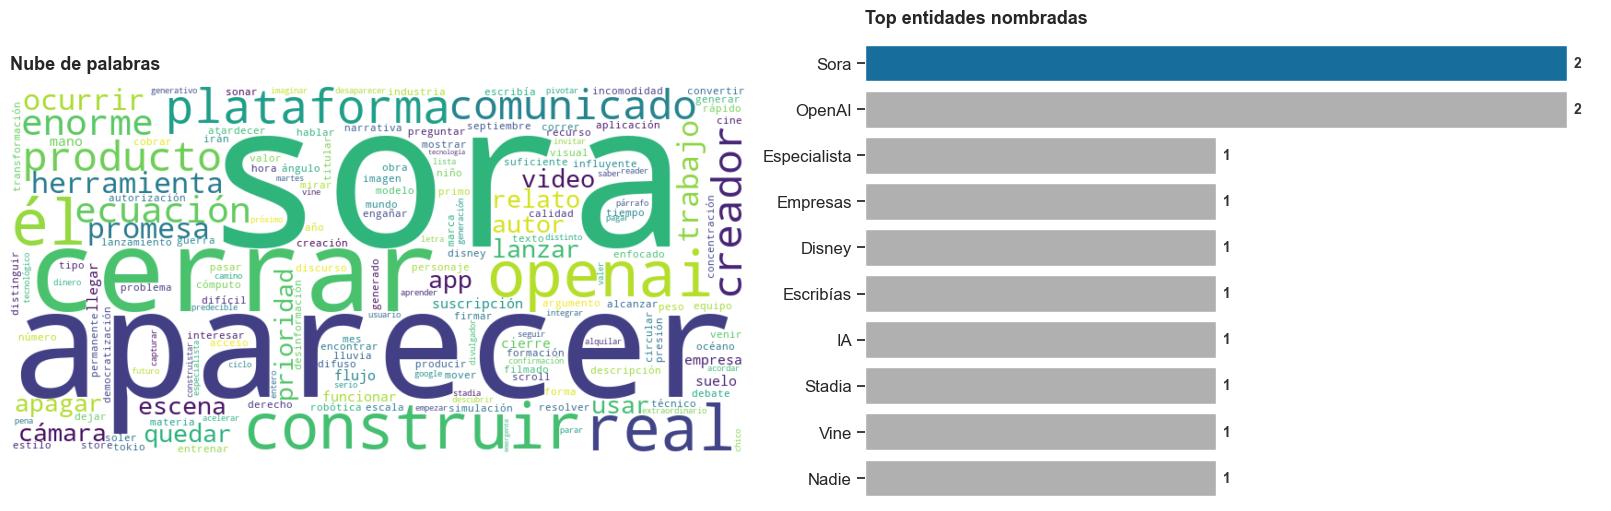

Fuente: cenital.com


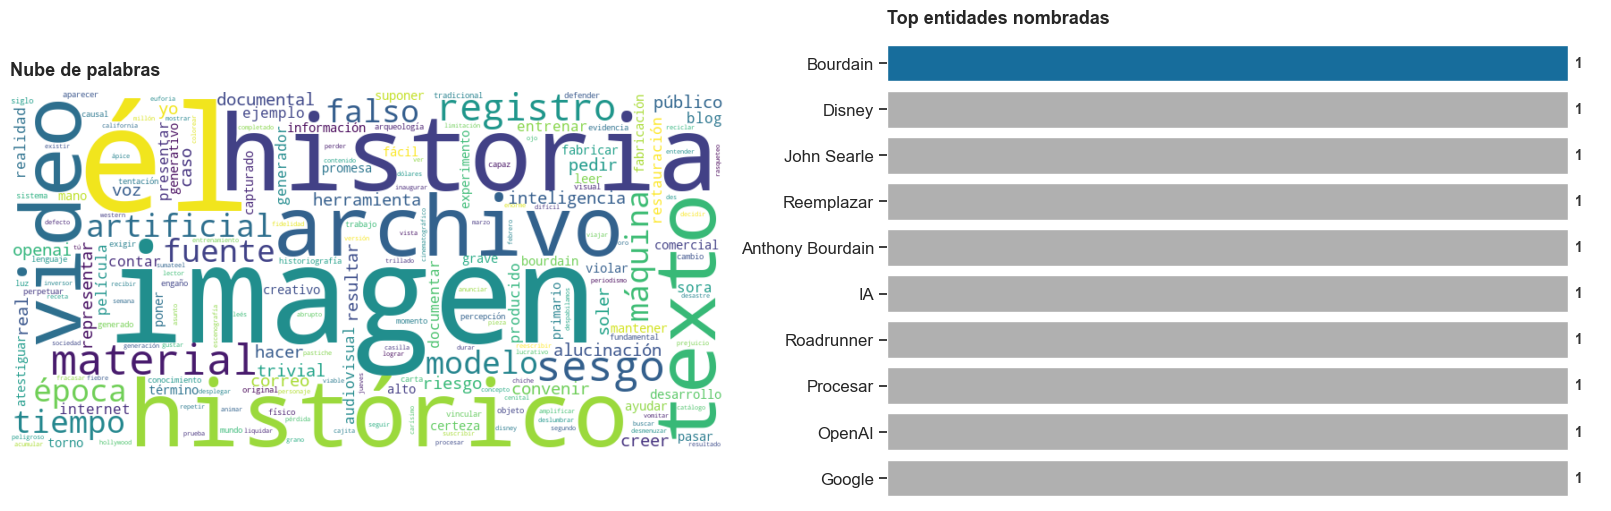

In [9]:
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.1)

for index, fila in df_web.iterrows():
    analizador = AnalizadorNoticia(fila['texto'], nlp)
    dict_entidades = analizador.obtener_entidades()

    print(f"Fuente: {fila['fuente']}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    palabras_relevantes = [
        token.lemma_.lower() 
        for token in analizador.doc 
        if not token.is_stop and not token.is_punct and token.is_alpha 
        and len(token.lemma_) > 2
        and token.pos_ in ['NOUN', 'VERB', 'PROPN', 'ADJ']
    ]
    texto_limpio = ' '.join(palabras_relevantes)

    if texto_limpio:
        wordcloud = WordCloud(
            width=800, height=400,
            background_color='white',
            collocations=False,
        ).generate(texto_limpio)
        axes[0].imshow(wordcloud, interpolation='bilinear')
        axes[0].axis('off')
        axes[0].set_title('Nube de palabras', fontsize=13, fontweight='bold', pad=12, loc='left')

    visualizar_entidades_mas_comunes(dict_entidades, ax=axes[1])

    plt.show()

*Comentarios:*
Acá se observan más entidades erróneas.

## Parte 4: integración en un pipeline (10 minutos)

**Objetivo:** integrar extracción, análisis y reporte agregado para varias noticias.

En esta parte conviene trabajar de menor a mayor:
1. probá con una sola URL;
2. verificá que el texto se extraiga;
3. recién después procesa una lista.


Iniciando procesamiento de 3 URLs...
Procesamiento completado.

--- REPORTE AGREGADO DE 3 NOTICIAS ---

--- ENTIDADES MAS COMUNES ---

--- VERBOS MAS COMUNES ---
[('representar', 2), ('lanzar', 2), ('generar', 2), ('permitir', 1), ('confirmar', 1), ('marcar', 1), ('implicar', 1), ('integrar', 1), ('atravesar', 1), ('ofrecer', 1), ('ampliar', 1), ('evolucionar', 1), ('convertir él', 1), ('crear', 1), ('compartir', 1)]


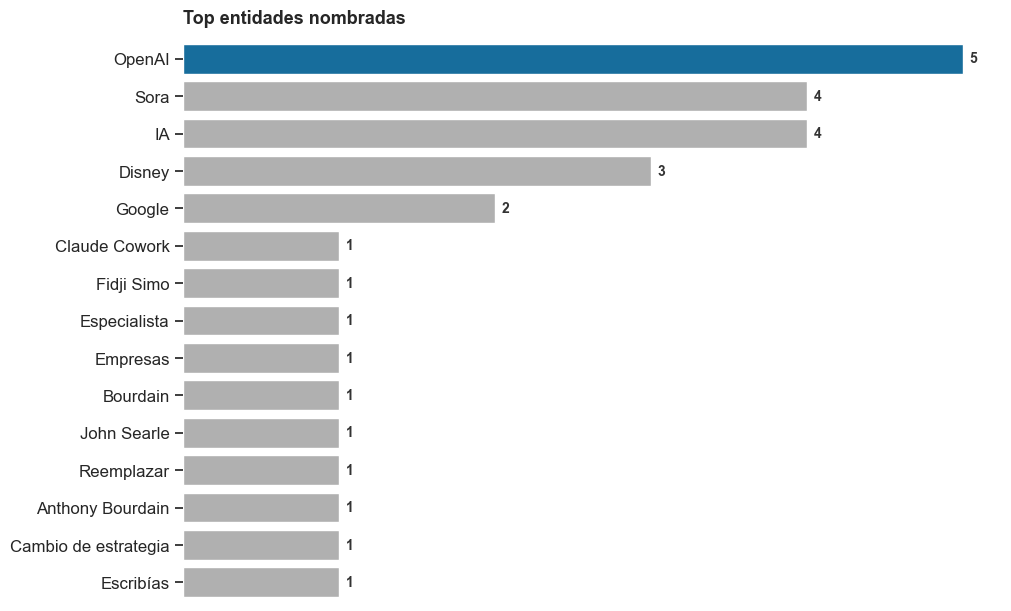

In [10]:
class AnalizadorTendencias:
    def __init__(self, lista_urls):
        self.urls = lista_urls
        self.noticias_data = []
        self.analizadores = []
        self.nlp = spacy.load("es_core_news_lg")

    def procesar_todas(self):
        """Orquesta la extracción y el análisis de todas las URLs."""
        print(f"Iniciando procesamiento de {len(self.urls)} URLs...")
        for url in self.urls:
            resultados = extraer_noticias_web([url])
            noticia = resultados[0] if resultados else None

            if noticia:
                self.noticias_data.append(noticia)
                analizador = AnalizadorNoticia(noticia['texto'], self.nlp)
                self.analizadores.append(analizador)

        print("Procesamiento completado.")

    def generar_reporte_agregado(self, n=15):
        """Genera un reporte consolidado de todas las noticias procesadas."""
        if not self.analizadores:
            print("No hay noticias procesadas para generar un reporte.")
            return

        todas_las_entidades = {
            "PERSONAS": [],
            "ORGANIZACIONES": [],
            "LUGARES": [],
            "OTROS": []
        }
        todos_los_verbos = []

        for analizador in self.analizadores:
            entidades = analizador.obtener_entidades()
            for clave in todas_las_entidades:
                todas_las_entidades[clave].extend(entidades[clave])
            verbos = analizador.obtener_verbos_principales(n=20)
            todos_los_verbos.extend([v[0] for v in verbos])

        print(f"\n--- REPORTE AGREGADO DE {len(self.analizadores)} NOTICIAS ---")
        print("\n--- ENTIDADES MAS COMUNES ---")
        visualizar_entidades_mas_comunes(todas_las_entidades, n=n)

        print("\n--- VERBOS MAS COMUNES ---")
        frecuencias_verbos = Counter(todos_los_verbos)
        print(frecuencias_verbos.most_common(n))

pipeline = AnalizadorTendencias(urls_noticias)
pipeline.procesar_todas()
pipeline.generar_reporte_agregado()

## Entregables, criterios de evaluación y cierre

### Entregables sugeridos
- Las funciones y clases completadas.
- Al menos una prueba con una noticia real.
- Una bitácora breve de interacción con IA.
- Una justificación corta sobre una decisión que tomaste a partir de una sugerencia de la IA y otra que descartaste.

### Criterios de evaluación
- **Funcionamiento técnico:** que el pipeline complete tareas básicas de extracción, análisis y visualización.
- **Juicio crítico:** que puedas explicar por qué elegiste una estrategia y no otra.
- **Uso de IA con criterio:** que la IA aparezca como apoyo de exploración, no como reemplazo del razonamiento.
- **Proceso documentado:** que la bitácora muestre qué tomaste, qué corregiste y qué descartaste.
- **Claridad del código:** que las funciones y clases sean legibles y consistentes.

### Checklist antes de entregar
- Probaste cada parte por separado antes de integrar todo?
- Podés explicar qué hace cada función principal?
- Tu bitácora muestra intervención humana real sobre los outputs de IA?
- Hay al menos un ejemplo donde corregiste o descartaste una sugerencia de la IA?

Si respondiste que sí a estas preguntas, tu laboratorio ya está alineado con la propuesta pedagógica de la cátedra.
